# DehazeDDPM：多 checkpoint 測試集視覺對比

四欄：**Input (fog)** / **GT** / **RESIDE-pretrain** / **Ours (finetune)**。

與 `infer.py` 的對應：驗證 dataloader **不 shuffle**，樣本順序與 `data/LRHR_dataset.py` 中 `paired_paths_from_folder`（`hazy_test` 的 `scandir` 順序）一致；第 `k` 個樣本（0-based）對應輸出檔名 **`{INFER_SAVE_STEP}_{k+1}_out.png`**、**`{INFER_SAVE_STEP}_{k+1}_lr.png`**。`infer.py` 裡 `current_step` 未在迴圈中更新，故預設為 **0**。

**解析度**：磁碟上的 `hazy_test` / `gt_test` 可能為原始高解析度；推理存下的 `_lr` / `_out` 經 `data/util.py` 的 `Resize((img_sizeH, img_sizeW))`（與 config 中 val 一致）。本 notebook 的 **Input** 欄使用結果目錄中的 `_lr.png`（與模型輸入一致）；**GT** 由 `gt_test` 讀取後以相同寬高縮放對齊，方便與三欄並列比較。

**注意**：`dehazeddpm_manifest_seed42.json` 的 `pairs` 順序與上述 dataloader 順序不一定相同，對齊推理結果時請以本 notebook 重建的路徑表為準，不要直接用 manifest 的 `index` 當檔名序號。

In [22]:
import os
from os import path as osp

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# --- 可依需求修改的四個變量 ---
PATH_TEST_DATAROOT = "/mnt/newdisk/Documents/linzhanyang/data/dehazeddpm_test"
PATH_RESULTS_RESIDE_PRETRAIN = "/mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/Dehaze_test_DENSE_diy_260418_100213/results"
PATH_RESULTS_OURS_FINETUNE = "/mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/Dehaze_ColdFog_finetune_test_netH_260418_004817/results"
# infer.py 存檔：f"{INFER_SAVE_STEP}_{idx}_out.png"，idx 從 1 開始
INFER_SAVE_STEP = 0

# 與 config 一致：hazy_test / gt_test 在目錄下
PATH_HAZY = osp.join(PATH_TEST_DATAROOT, "hazy_test")
PATH_GT = osp.join(PATH_TEST_DATAROOT, "gt_test")

# Matplotlib：英文標籤，Times New Roman（全劇本開頭配置一次）
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
plt.rcParams["axes.unicode_minus"] = False

In [23]:
def scandir_files(dir_path, suffix=None, recursive=False, full_path=False):
    """Mirror LRHRDataset.scandir (returns list of relative paths under dir_path)."""
    root = dir_path

    def _scandir(dp, suf, rec):
        out = []
        for entry in os.scandir(dp):
            if not entry.name.startswith(".") and entry.is_file():
                return_path = entry.path if full_path else osp.relpath(entry.path, root)
                if suf is None or return_path.endswith(suf):
                    out.append(return_path)
            elif entry.is_dir() and rec:
                out.extend(_scandir(entry.path, suf, rec))
        return out

    return _scandir(dir_path, suffix, recursive)


def build_paired_paths(input_folder, gt_folder):
    """Same pairing order as data/LRHR_dataset.py LRHRDataset.paired_paths_from_folder."""
    input_paths = scandir_files(input_folder)
    paths = []
    for lq_path in input_paths:
        basename, ext = osp.splitext(osp.basename(lq_path))
        input_name = basename + ext
        gt_path_full = osp.join(gt_folder, input_name)
        input_path_full = osp.join(input_folder, lq_path)
        paths.append({"lq_path": input_path_full, "gt_path": gt_path_full, "name": input_name})
    return paths


def load_rgb(path):
    return np.asarray(Image.open(path).convert("RGB"))


def load_gt_matched_to_lr(gt_path, lr_hw):
    """Resize GT to (H,W) of network input / outputs for side-by-side display."""
    h, w = lr_hw
    im = Image.open(gt_path).convert("RGB").resize((w, h), Image.LANCZOS)
    return np.asarray(im)


def fog_density_label(filename):
    """Parse fog level from names like ``*_heavy.jpg`` / ``*_medium.jpg`` / ``*_low.jpg`` (figure text in English)."""
    stem = osp.splitext(filename)[0]
    key = stem.split("_")[-1].lower()
    return {"heavy": "Heavy", "medium": "Medium", "low": "Low"}.get(key, key.replace("_", " ").title())


paired = build_paired_paths(PATH_HAZY, PATH_GT)
print(f"Paired samples: {len(paired)}")
print("First 3 (dataloader order):", [p["name"] for p in paired[:3]])
print("Example outputs:", osp.join(PATH_RESULTS_OURS_FINETUNE, f"{INFER_SAVE_STEP}_1_out.png"))

Paired samples: 80
First 3 (dataloader order): ['ggl_20260202_0064_medium.jpg', 'sdm_20260204_0213_low.jpg', 'ggl_20260202_0013_heavy.jpg']
Example outputs: /mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/Dehaze_ColdFog_finetune_test_netH_260418_004817/results/0_1_out.png


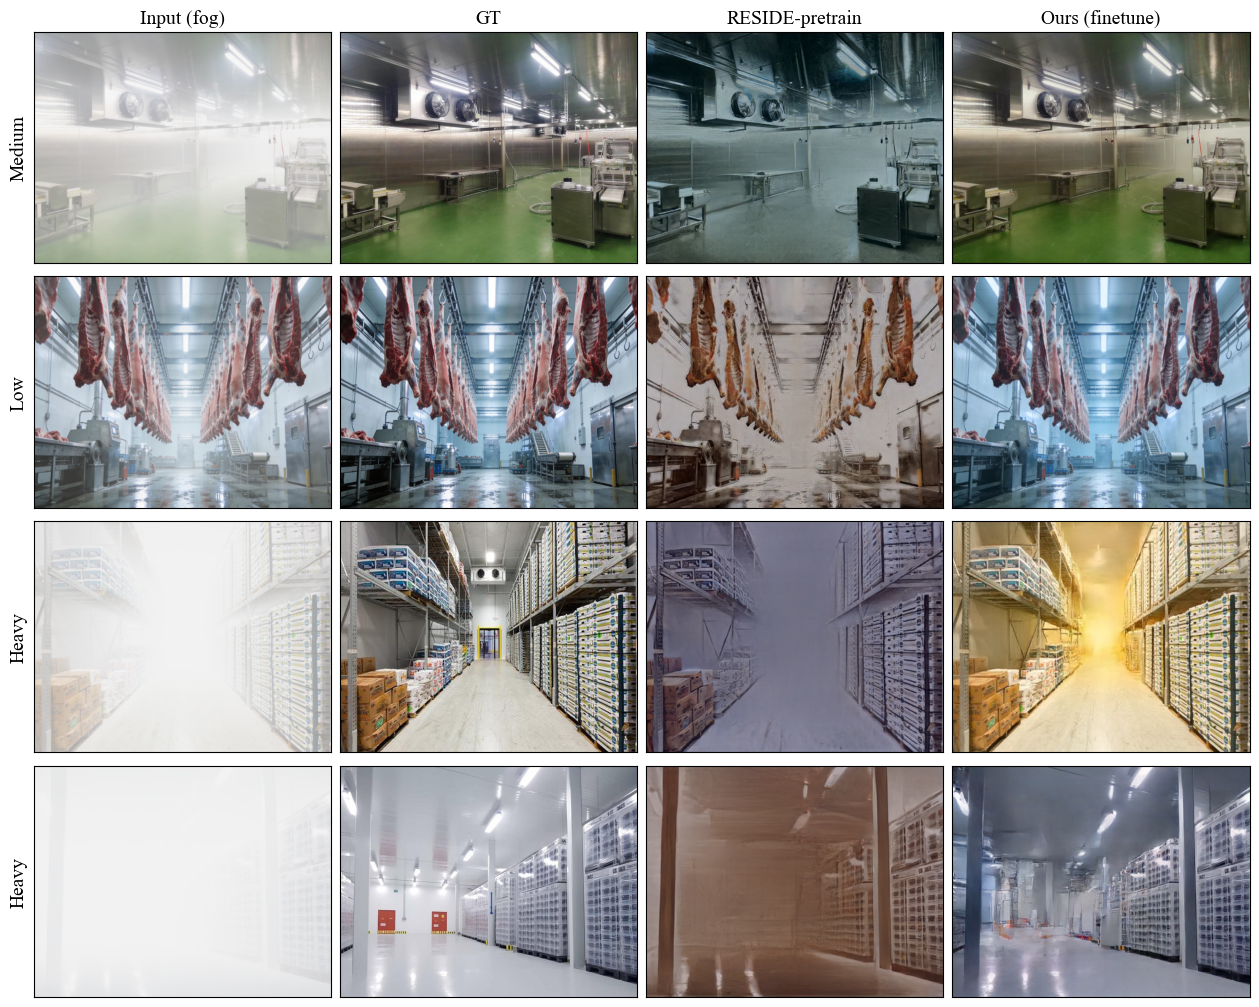

In [24]:
def show_comparison_grid(
    paired_list,
    results_pretrain,
    results_ours,
    infer_step=0,
    row_indices=None,
    figsize_per_col=3.2,
):
    """Each row: same scene; columns: fog (saved _lr) / GT resized / pretrain / ours. Does not save files."""
    if row_indices is None:
        row_indices = list(range(min(6, len(paired_list))))

    n = len(row_indices)

    # Figure height should follow image aspect ratio; otherwise each row gets extra blank space.
    sample_i0 = row_indices[0]
    lr_ours0 = osp.join(results_ours, f"{infer_step}_{sample_i0 + 1}_lr.png")
    lr_pre0 = osp.join(results_pretrain, f"{infer_step}_{sample_i0 + 1}_lr.png")
    if osp.isfile(lr_ours0):
        fog0 = load_rgb(lr_ours0)
    elif osp.isfile(lr_pre0):
        fog0 = load_rgb(lr_pre0)
    else:
        fog0 = load_rgb(paired_list[sample_i0]["lq_path"])
    img_h, img_w = fog0.shape[:2]
    img_aspect = img_h / img_w

    fig_width = 4 * figsize_per_col
    fig_height = n * figsize_per_col * img_aspect * 1.03 + 0.45
    fig, axes = plt.subplots(
        n,
        4,
        figsize=(fig_width, fig_height),
        gridspec_kw={"hspace": 0.02, "wspace": 0.03},
    )
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    col_titles = ["Input (fog)", "GT", "RESIDE-pretrain", "Ours (finetune)"]
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=14)

    for r, sample_i in enumerate(row_indices):
        p = paired_list[sample_i]
        idx1 = sample_i + 1
        lr_ours = osp.join(results_ours, f"{infer_step}_{idx1}_lr.png")
        lr_pre = osp.join(results_pretrain, f"{infer_step}_{idx1}_lr.png")
        if osp.isfile(lr_ours):
            fog = load_rgb(lr_ours)
        elif osp.isfile(lr_pre):
            fog = load_rgb(lr_pre)
        else:
            fog = load_rgb(p["lq_path"])
        gt = load_gt_matched_to_lr(p["gt_path"], fog.shape[:2])
        pre_path = osp.join(results_pretrain, f"{infer_step}_{idx1}_out.png")
        ours_path = osp.join(results_ours, f"{infer_step}_{idx1}_out.png")

        row_axes = axes[r]
        row_axes[0].imshow(fog)
        row_axes[1].imshow(gt)

        if osp.isfile(pre_path):
            row_axes[2].imshow(load_rgb(pre_path))
        else:
            row_axes[2].text(0.5, 0.5, "missing", ha="center", va="center", transform=row_axes[2].transAxes)
            row_axes[2].set_facecolor("#e0e0e0")

        if osp.isfile(ours_path):
            row_axes[3].imshow(load_rgb(ours_path))
        else:
            row_axes[3].text(0.5, 0.5, "missing", ha="center", va="center", transform=row_axes[3].transAxes)
            row_axes[3].set_facecolor("#e0e0e0")

        # row_axes[0].set_ylabel(p["name"][:32] + ("…" if len(p["name"]) > 32 else ""), fontsize=8)
        row_axes[0].set_ylabel(fog_density_label(p["name"]), fontsize=14)
        for ax in row_axes:
            ax.set_xticks([])
            ax.set_yticks([])

    fig.subplots_adjust(left=0.045, right=0.995, top=0.94, bottom=0.03, hspace=0.02, wspace=0.03)
    plt.show()


# 要顯示的列（場景）：0-based 對應 paired 順序；改這裡挑冷庫場景
ROW_INDICES = [0, 1, 2, 3, ]

show_comparison_grid(
    paired,
    PATH_RESULTS_RESIDE_PRETRAIN,
    PATH_RESULTS_OURS_FINETUNE,
    infer_step=INFER_SAVE_STEP,
    row_indices=ROW_INDICES,
)